In [1]:
!pip install ultralytics roboflow -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 140.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 6.9 MB/s eta 0:00:00


In [2]:
from roboflow import Roboflow

rf = Roboflow(api_key="dummy api key")
project = rf.workspace("adarsh-singh-dummy project").project("construction_object-detection")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Construction_Object-Detection-1 in yolov8:: 100%|██████████| 37437/37437 [00:07<00:00, 5063.68it/s]


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [3]:
from ultralytics import YOLO

# Load your trained model
model = YOLO('best.pt')

# Evaluate the model on the unseen test dataset
metrics = model.val(
    data=f"{dataset.location}/data.yaml",
    split='test',  # Focuses only on the test images
    imgsz=640,
    device=0       # Uses the GPU
)

print(f"Test mAP50-95: {metrics.box.map}")

Ultralytics 8.4.136 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,128,680 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1523.3±446.1 MB/s, size: 67.5 KB)
val: Scanning /content/Construction_Object-Detection-1/test/labels... 1070 images, 56 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1070/1070 923.0it/s 1.2s
val: New cache created: /content/Construction_Object-Detection-1/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 10391, len(boxes) = 37643. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
WARNING ⚠️ Dataset images contain up to 675 objects (test=675), but max_det=300. This mismatch can cap recall and produce invalid validation metrics. Raising it may increase validation cost but cannot increase model or export capacity, wh


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1070 /content/Construction_Object-Detection-1/test/images/0000159_jpg.rf.552ef0fcca40c06ff2173b0f5425d071.jpg: 640x640 1 Bulldozer, 16.9ms
image 2/1070 /content/Construction_Object-Detection-1/test/images/0000271_jpg.rf.468aaaa249336c372deca31c9615c681.jpg: 640x640 1 Bulldozer, 16.3ms
image 3/1070 /content/Construction_Object-Detection-1/test/images/0000277_jpg.rf.c544250a4fa15d9db01ecc5fdb0d777c.jpg: 640x640 1 Bulldozer, 16.3ms
image 4/1070 /cont

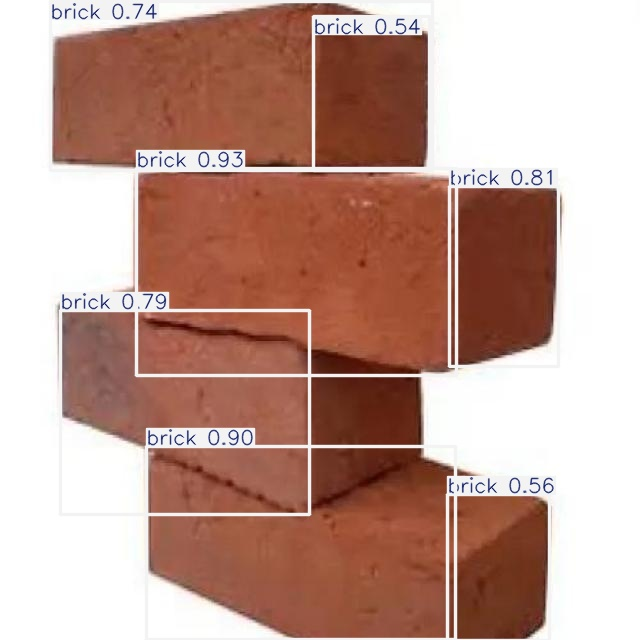

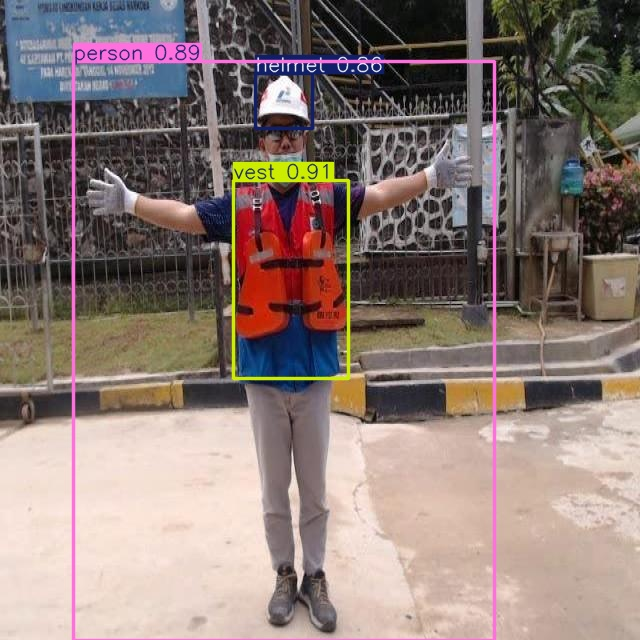

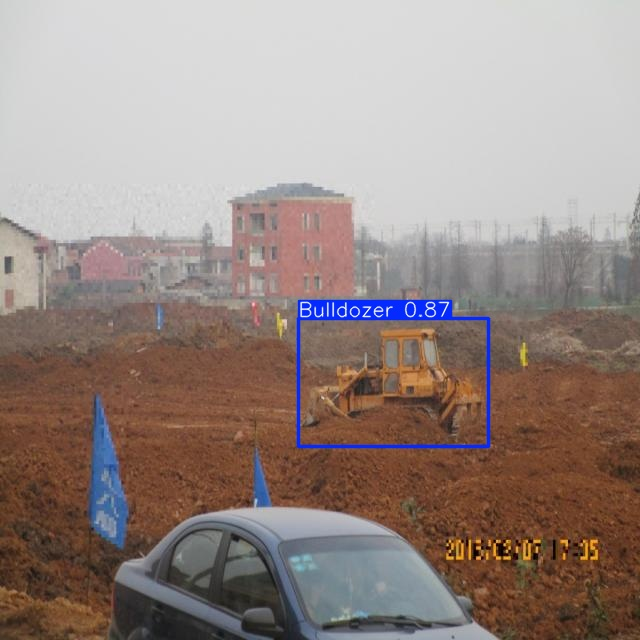

In [4]:
import glob
from IPython.display import Image, display

# Run predictions and save images with bounding boxes
test_images_path = f"{dataset.location}/test/images"
results = model.predict(source=test_images_path, conf=0.5, save=True, line_width=2)

# Find where the predicted images were saved (usually /content/runs/detect/predict)
save_dir = results[0].save_dir
predicted_images = glob.glob(f"{save_dir}/*.jpg")

# Display the first 3 test images inline
print("Sample Test Predictions:")
for img_path in predicted_images[:3]:
    display(Image(filename=img_path, width=600))

In [5]:
from ultralytics import YOLO

# 1. Load your trained model (update the path if your model is in Google Drive)
model = YOLO('best.pt')

# 2. Run validation on the test dataset
# Note: Ensure the path to your data.yaml matches your current Colab environment
dataset_yaml = f"{dataset.location}/data.yaml"
metrics = model.val(data=dataset_yaml, split='test')

# 3. Extract Precision and Recall from the results dictionary
precision = metrics.results_dict['metrics/precision(B)']
recall = metrics.results_dict['metrics/recall(B)']
map50 = metrics.results_dict['metrics/mAP50(B)']
map50_95 = metrics.results_dict['metrics/mAP50-95(B)']

# 4. Calculate the F1 Score
# Formula: 2 * (Precision * Recall) / (Precision + Recall)
if (precision + recall) > 0:
    f1_score = 2 * (precision * recall) / (precision + recall)
else:
    f1_score = 0.0

# 5. Print the results
print("-" * 30)
print("MODEL EVALUATION METRICS")
print("-" * 30)
print(f"Precision:  {precision:.4f}")
print(f"Recall:     {recall:.4f}")
print(f"F1 Score:   {f1_score:.4f}")
print(f"mAP@50:     {map50:.4f}")
print(f"mAP@50-95:  {map50_95:.4f}")
print("-" * 30)

Ultralytics 8.4.136 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,128,680 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2056.0±718.0 MB/s, size: 93.1 KB)
val: Scanning /content/Construction_Object-Detection-1/test/labels.cache... 1070 images, 56 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1070/1070 249.3Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 10391, len(boxes) = 37643. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
WARNING ⚠️ Dataset images contain up to 675 objects (test=675), but max_det=300. This mismatch can cap recall and produce invalid validation metrics. Raising it may increase validation cost but cannot increase model or export capacity, which may cap recall. Setting max_det=675 to match the observed maximum.
     

Found 6 validation plots. Displaying them now:

--- BoxP_curve.png ---


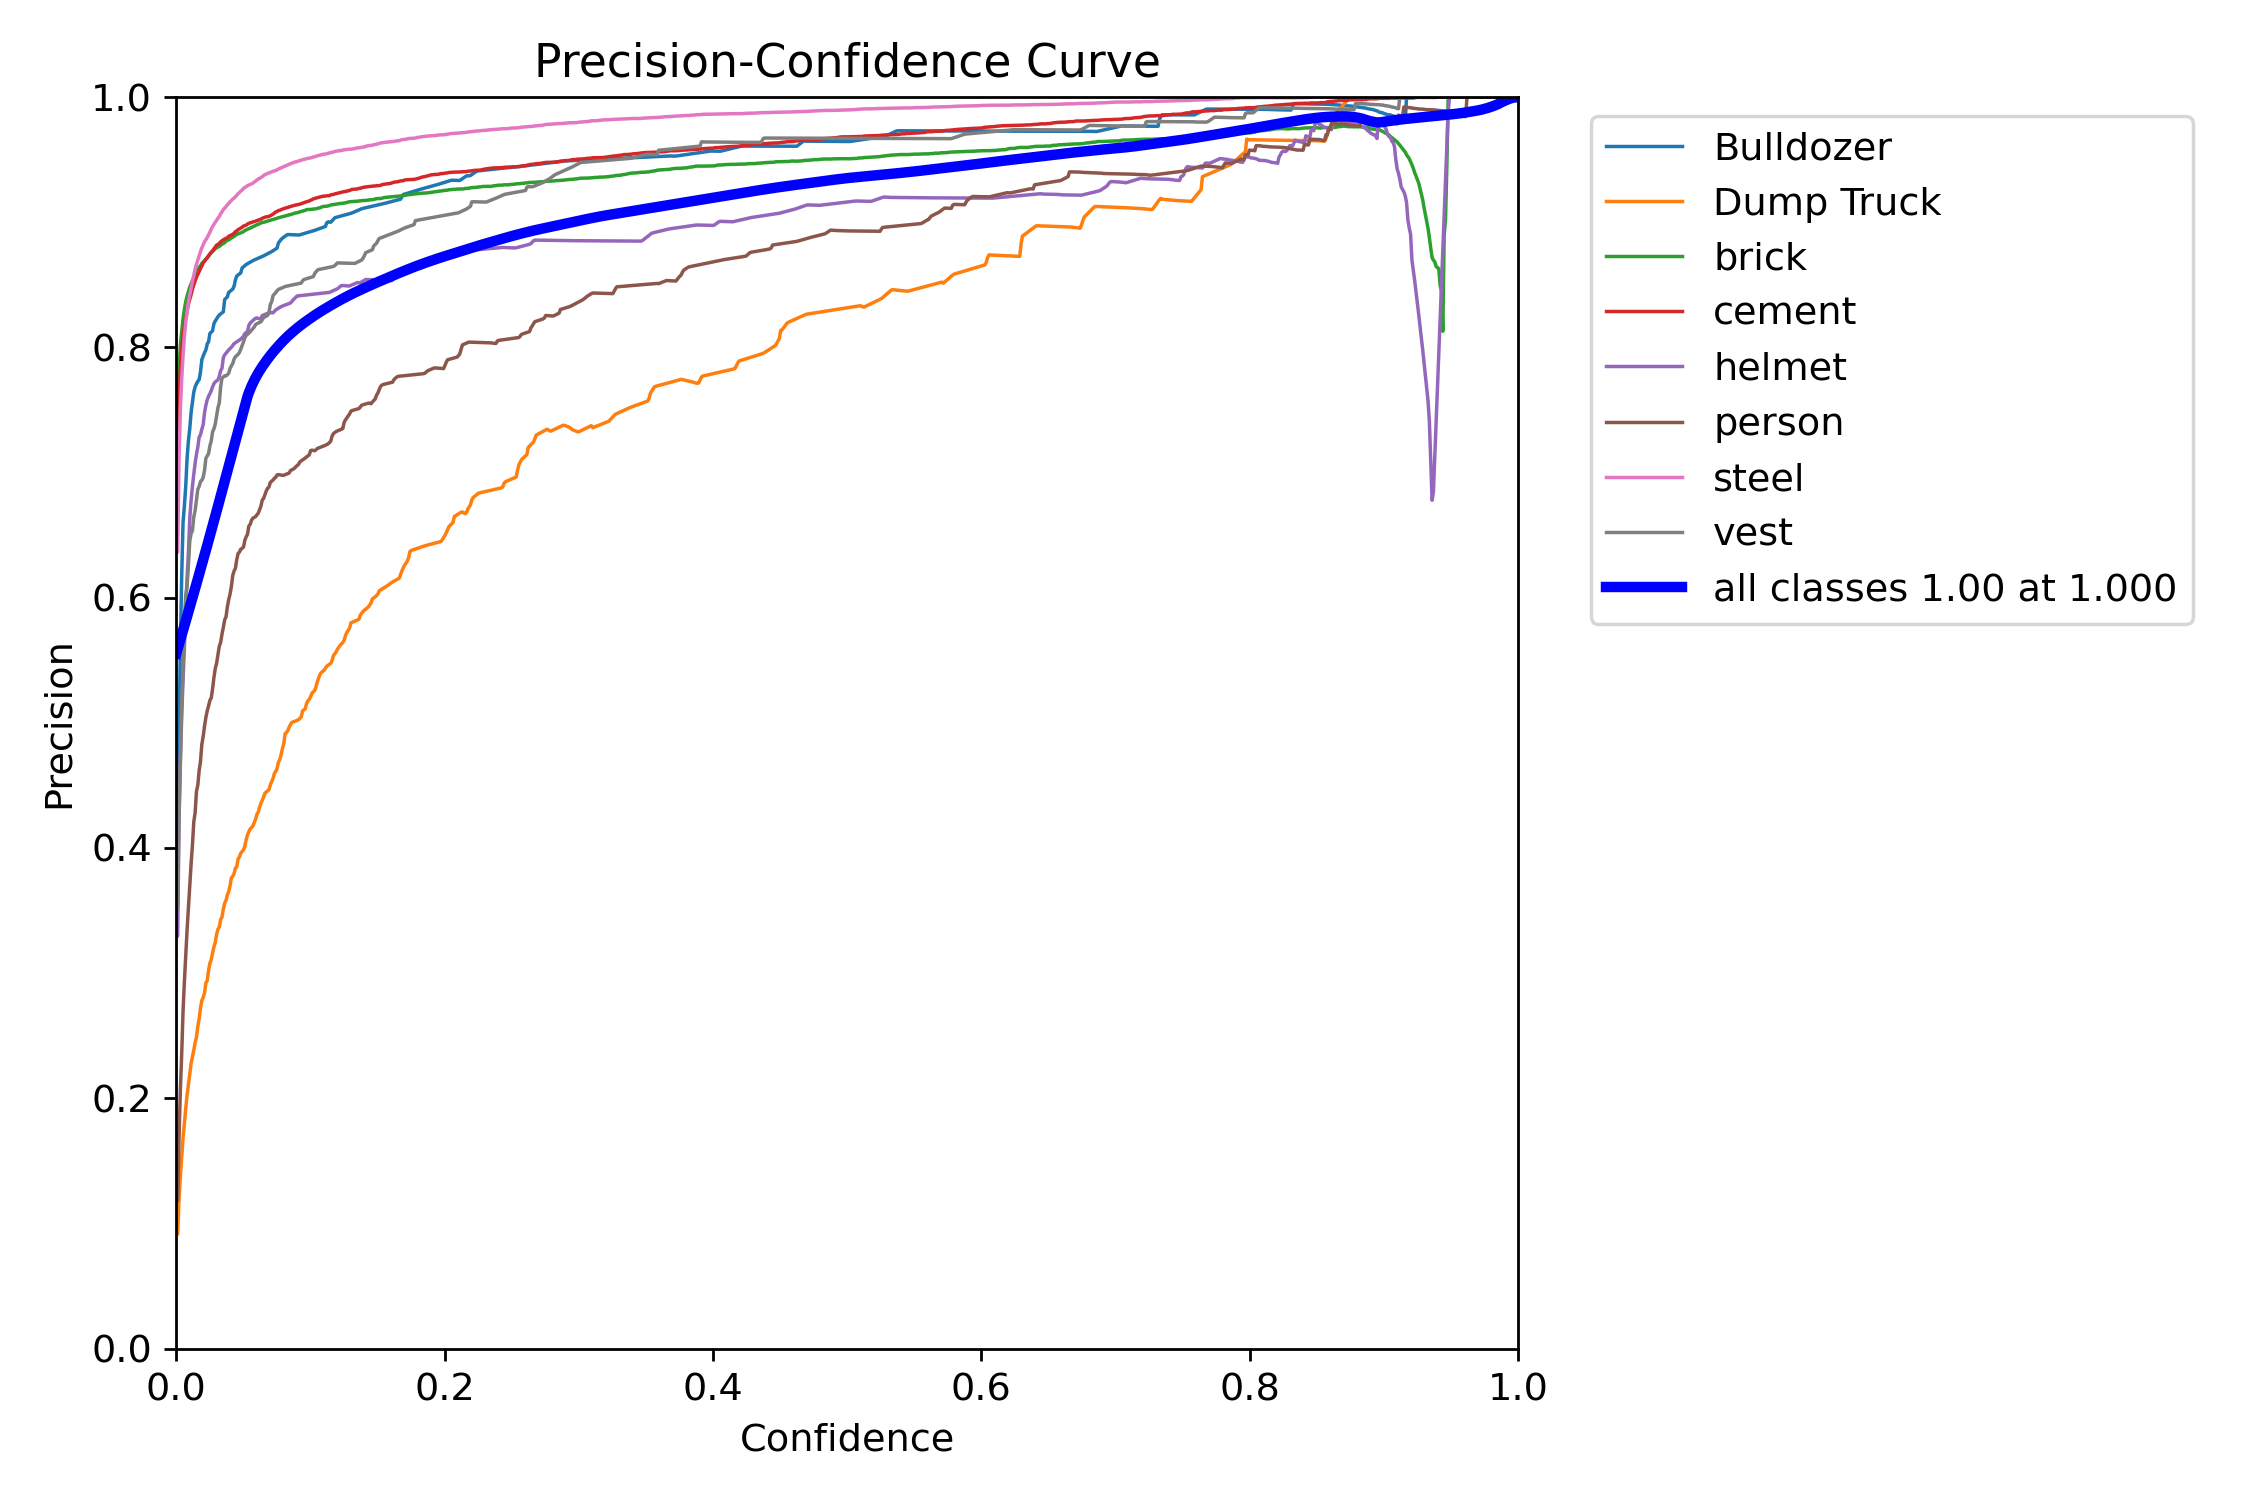

--- BoxF1_curve.png ---


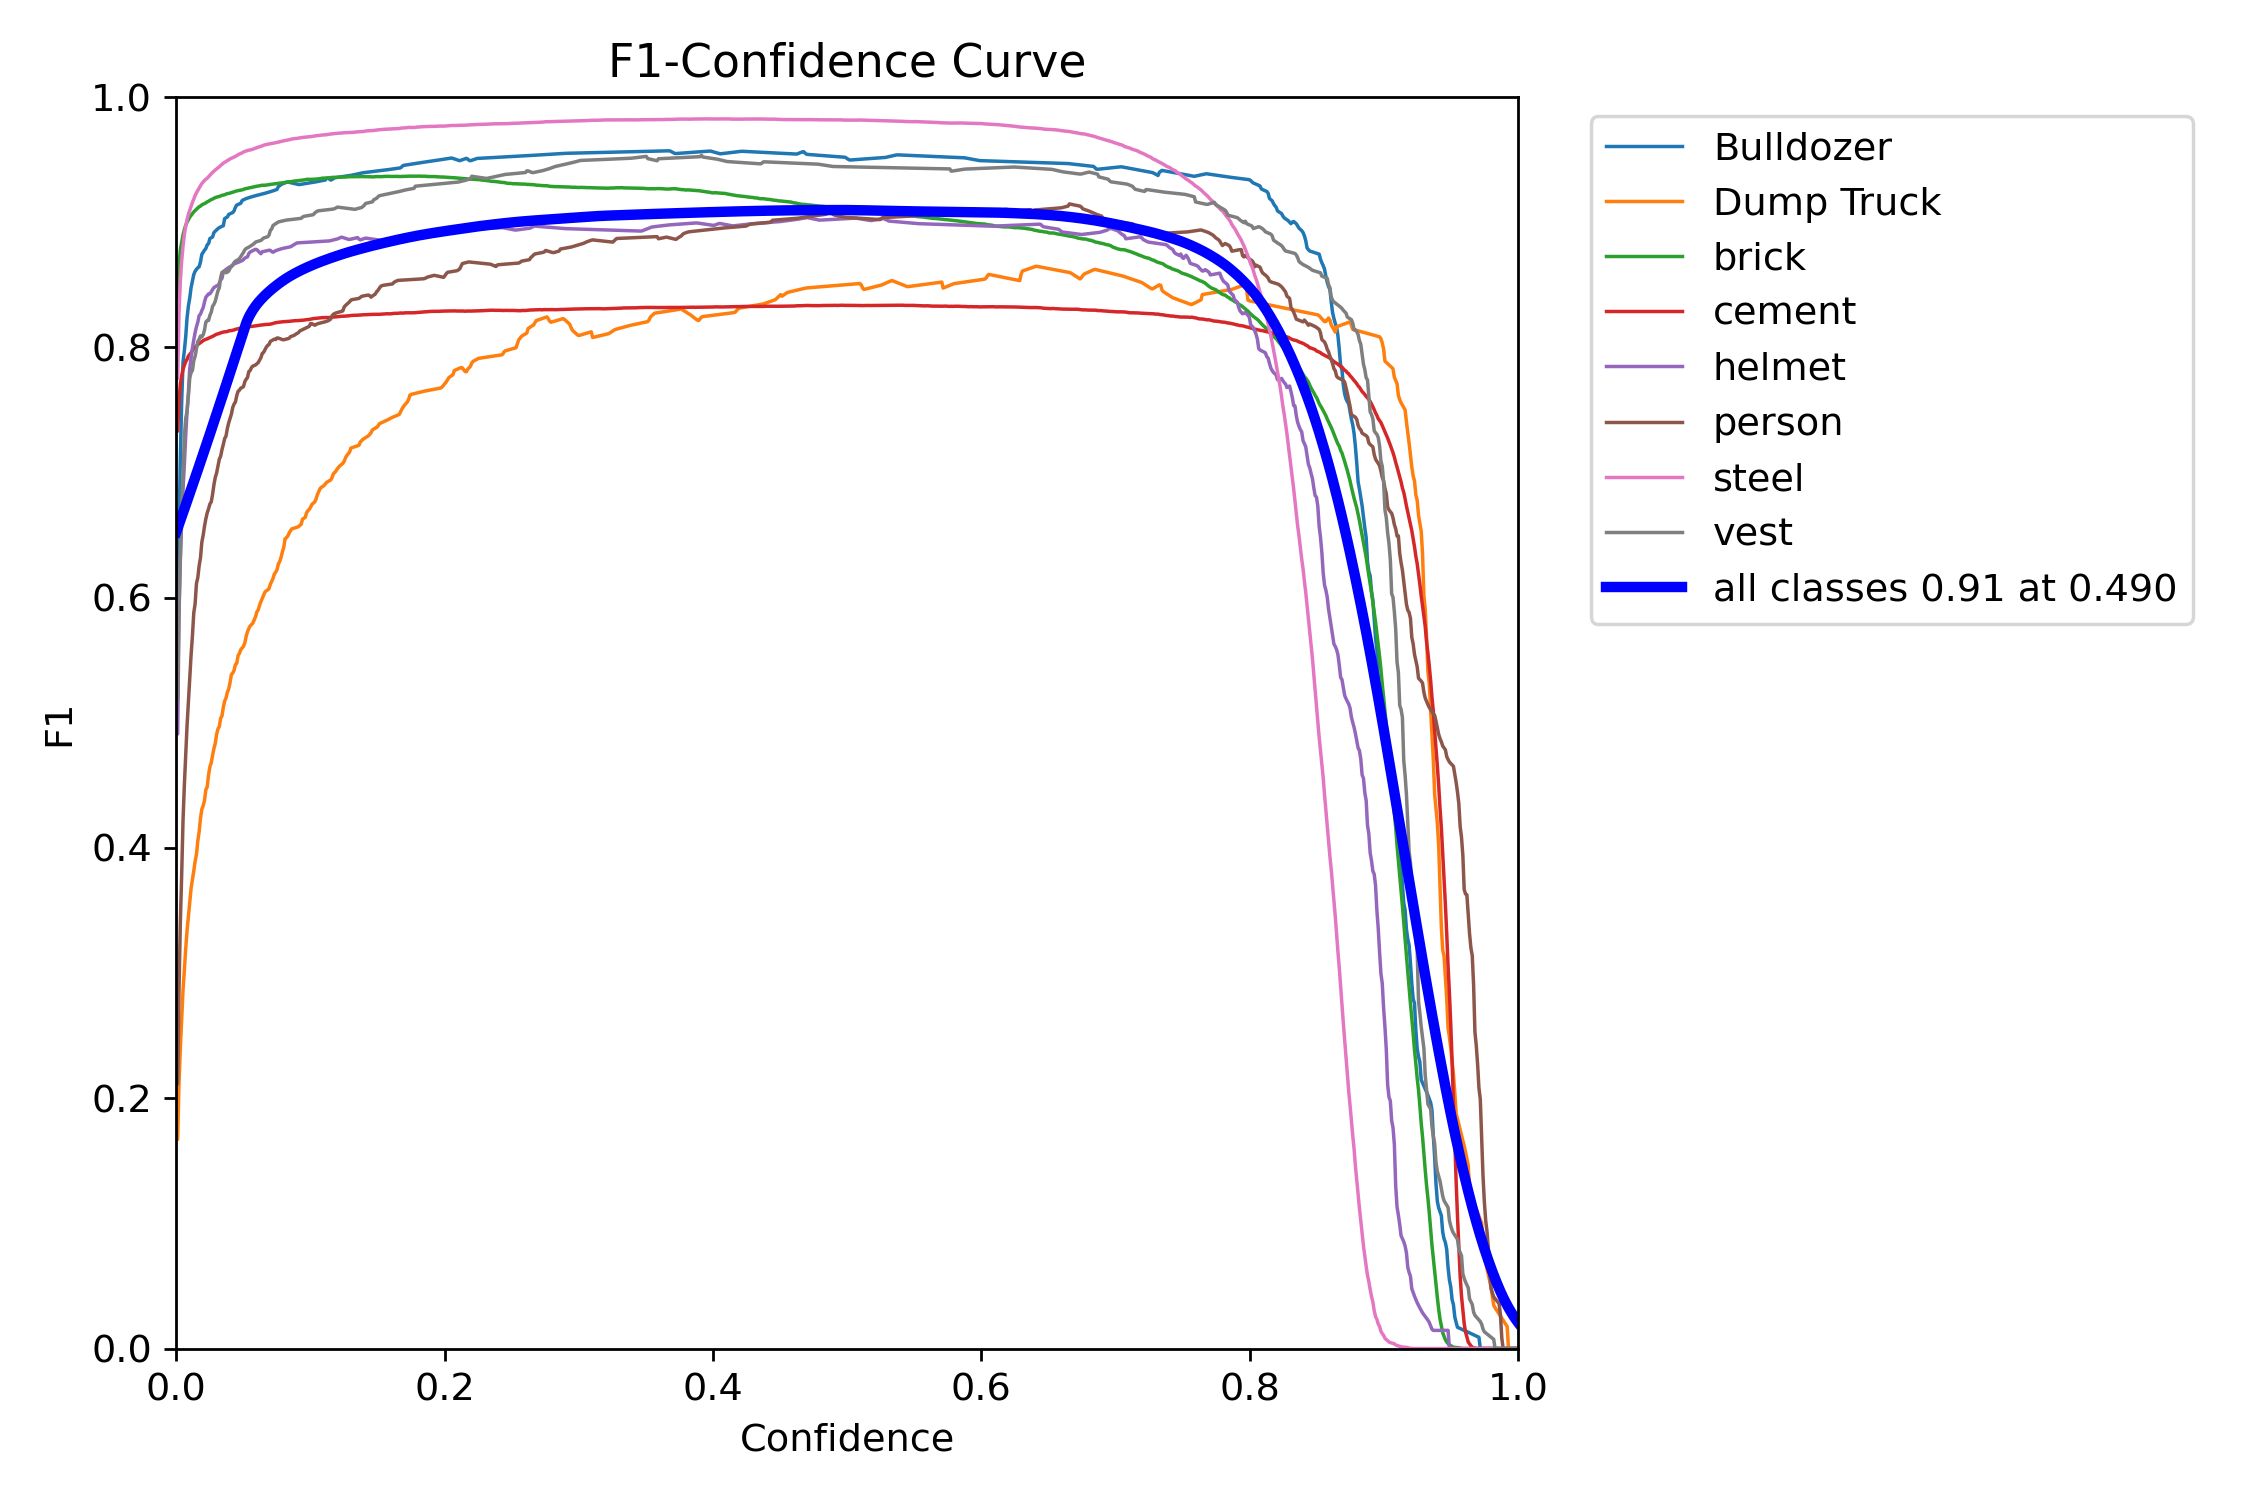

--- BoxR_curve.png ---


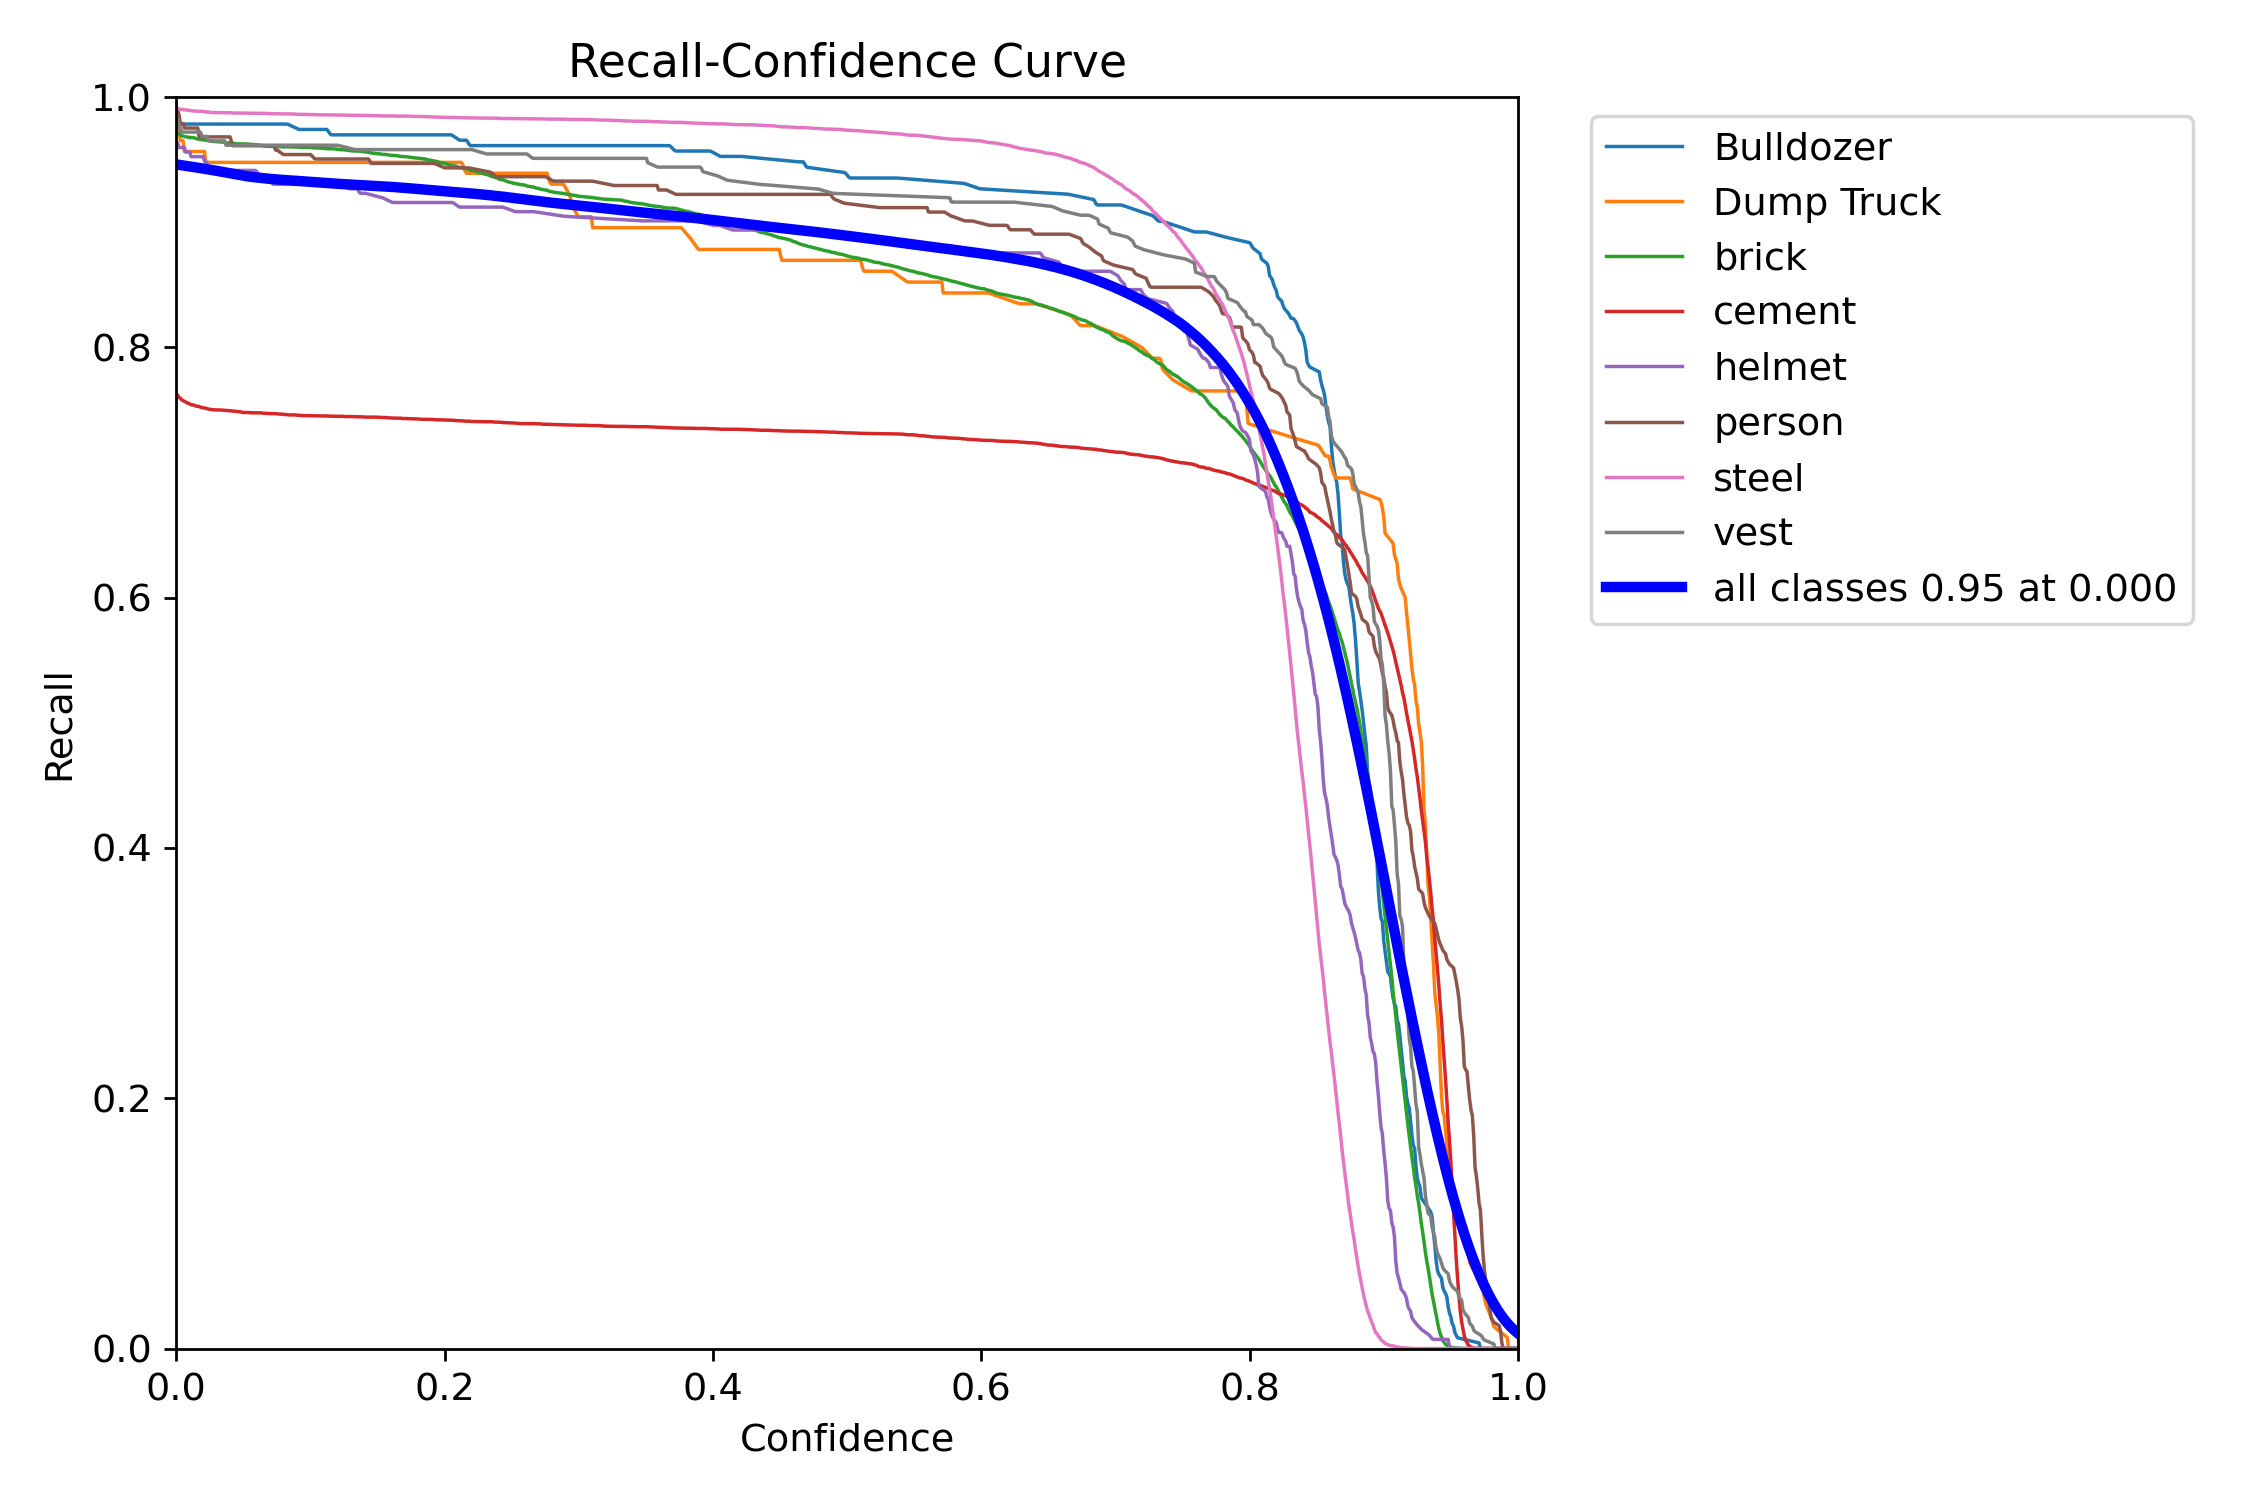

--- BoxPR_curve.png ---


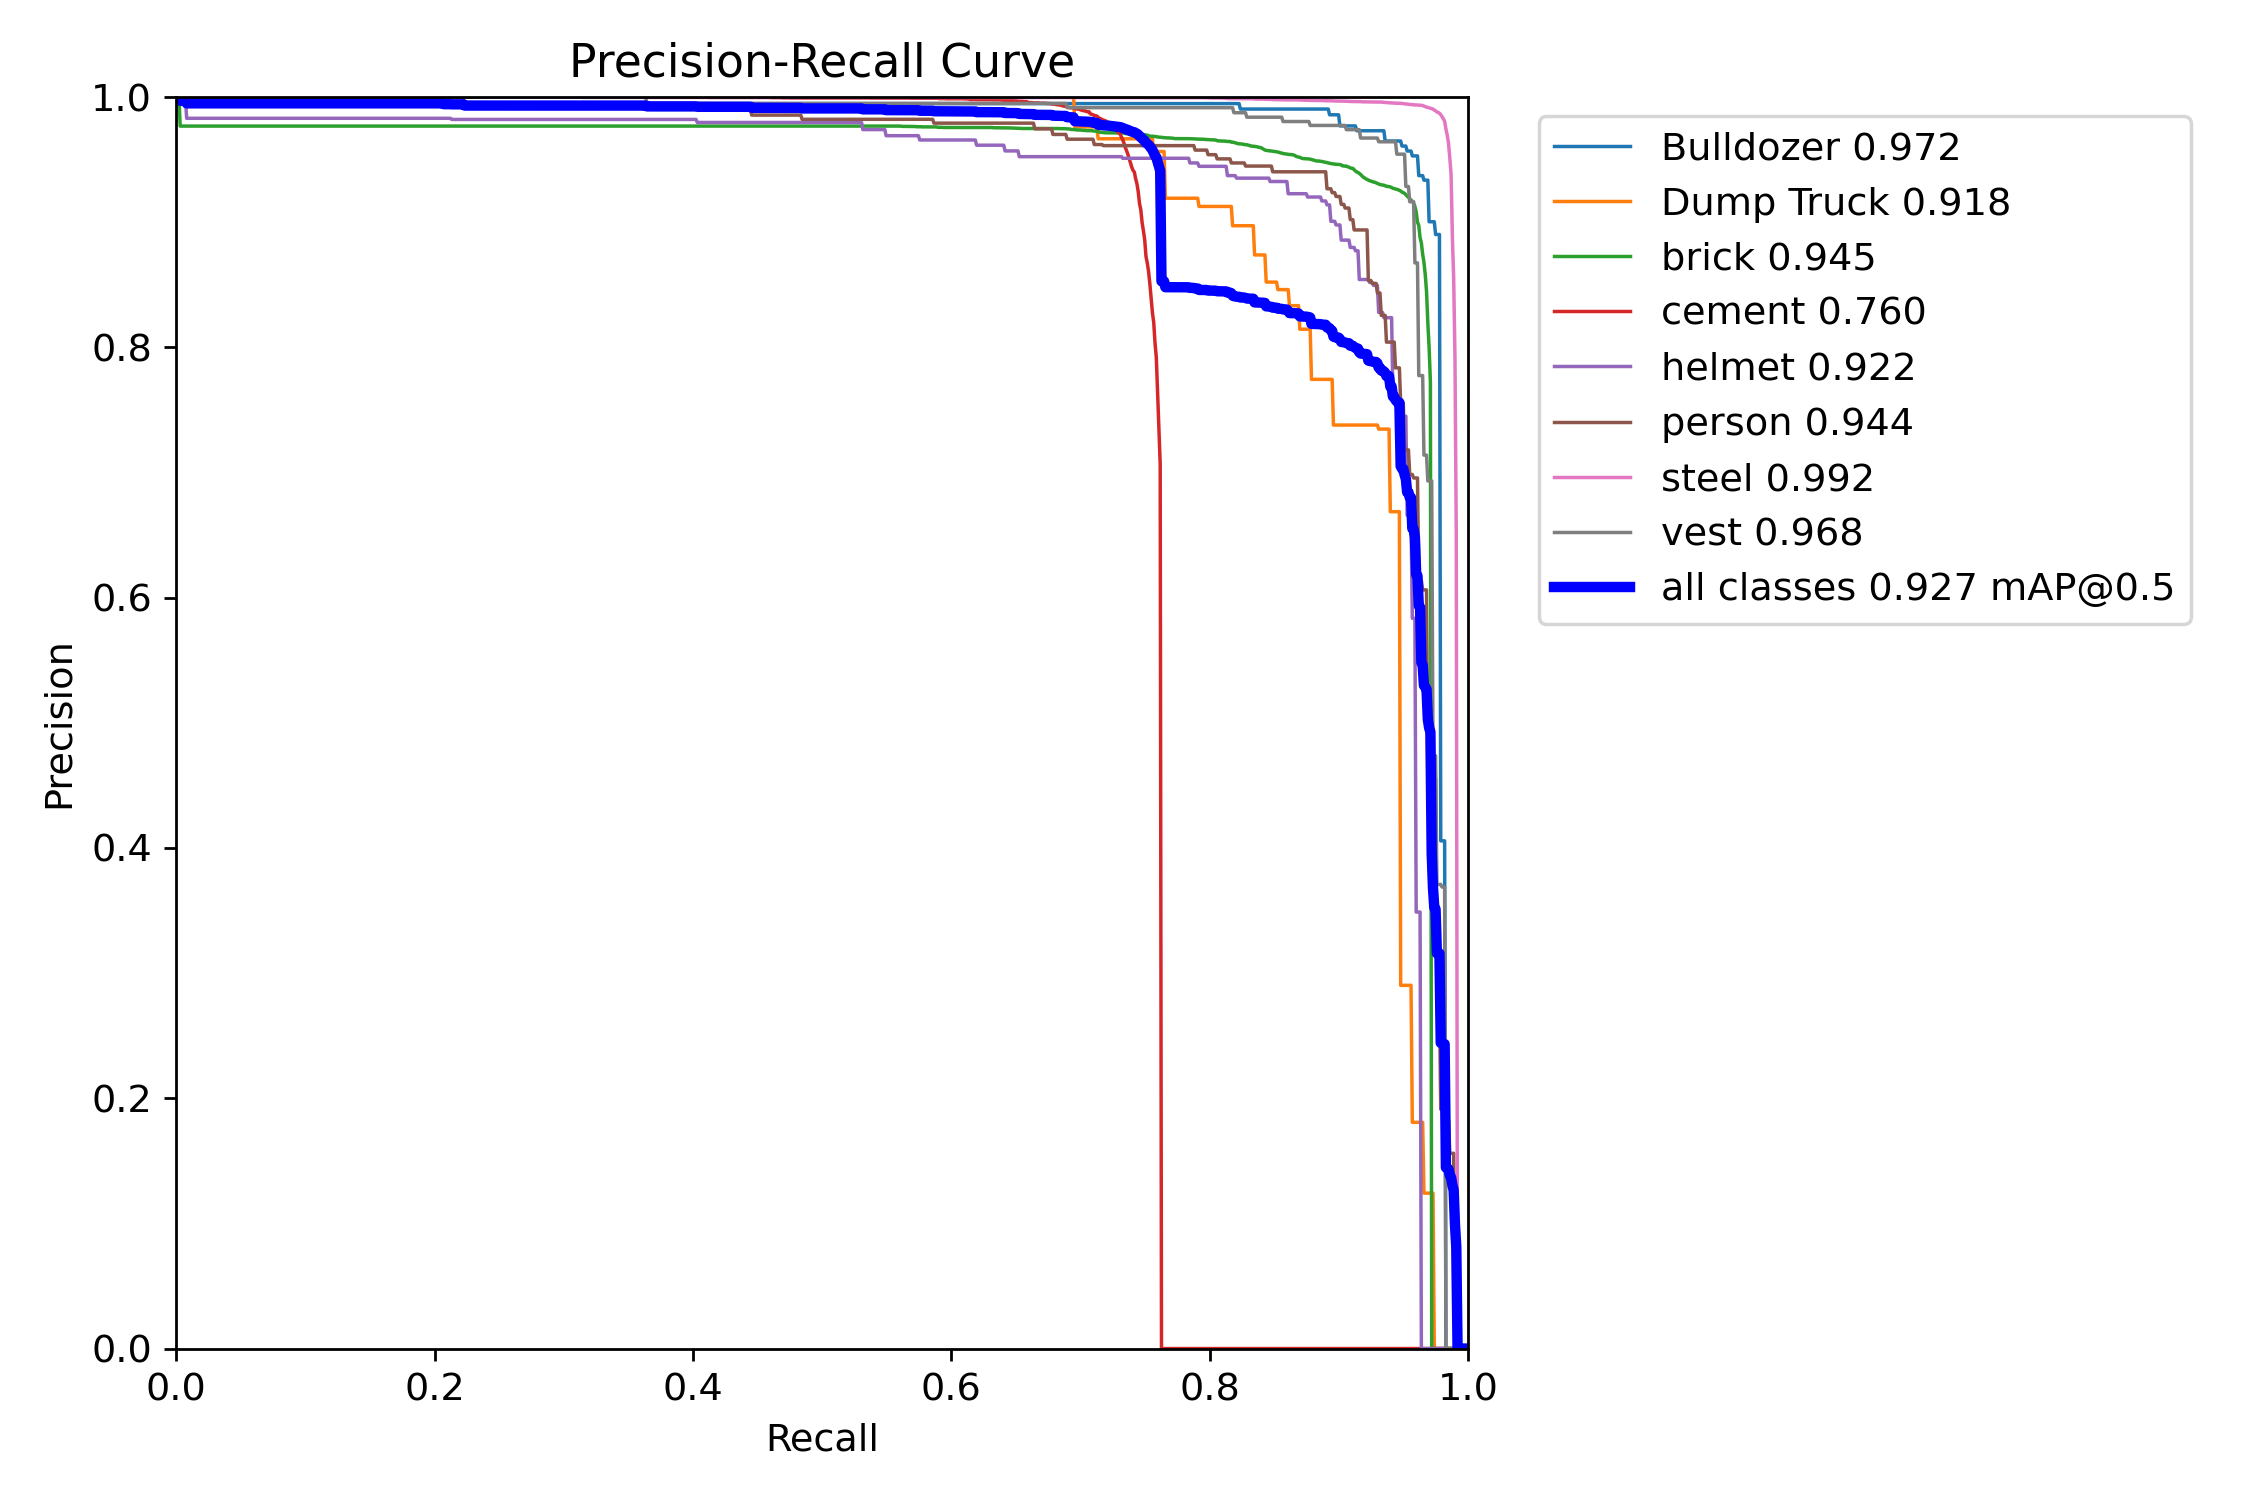

--- confusion_matrix_normalized.png ---


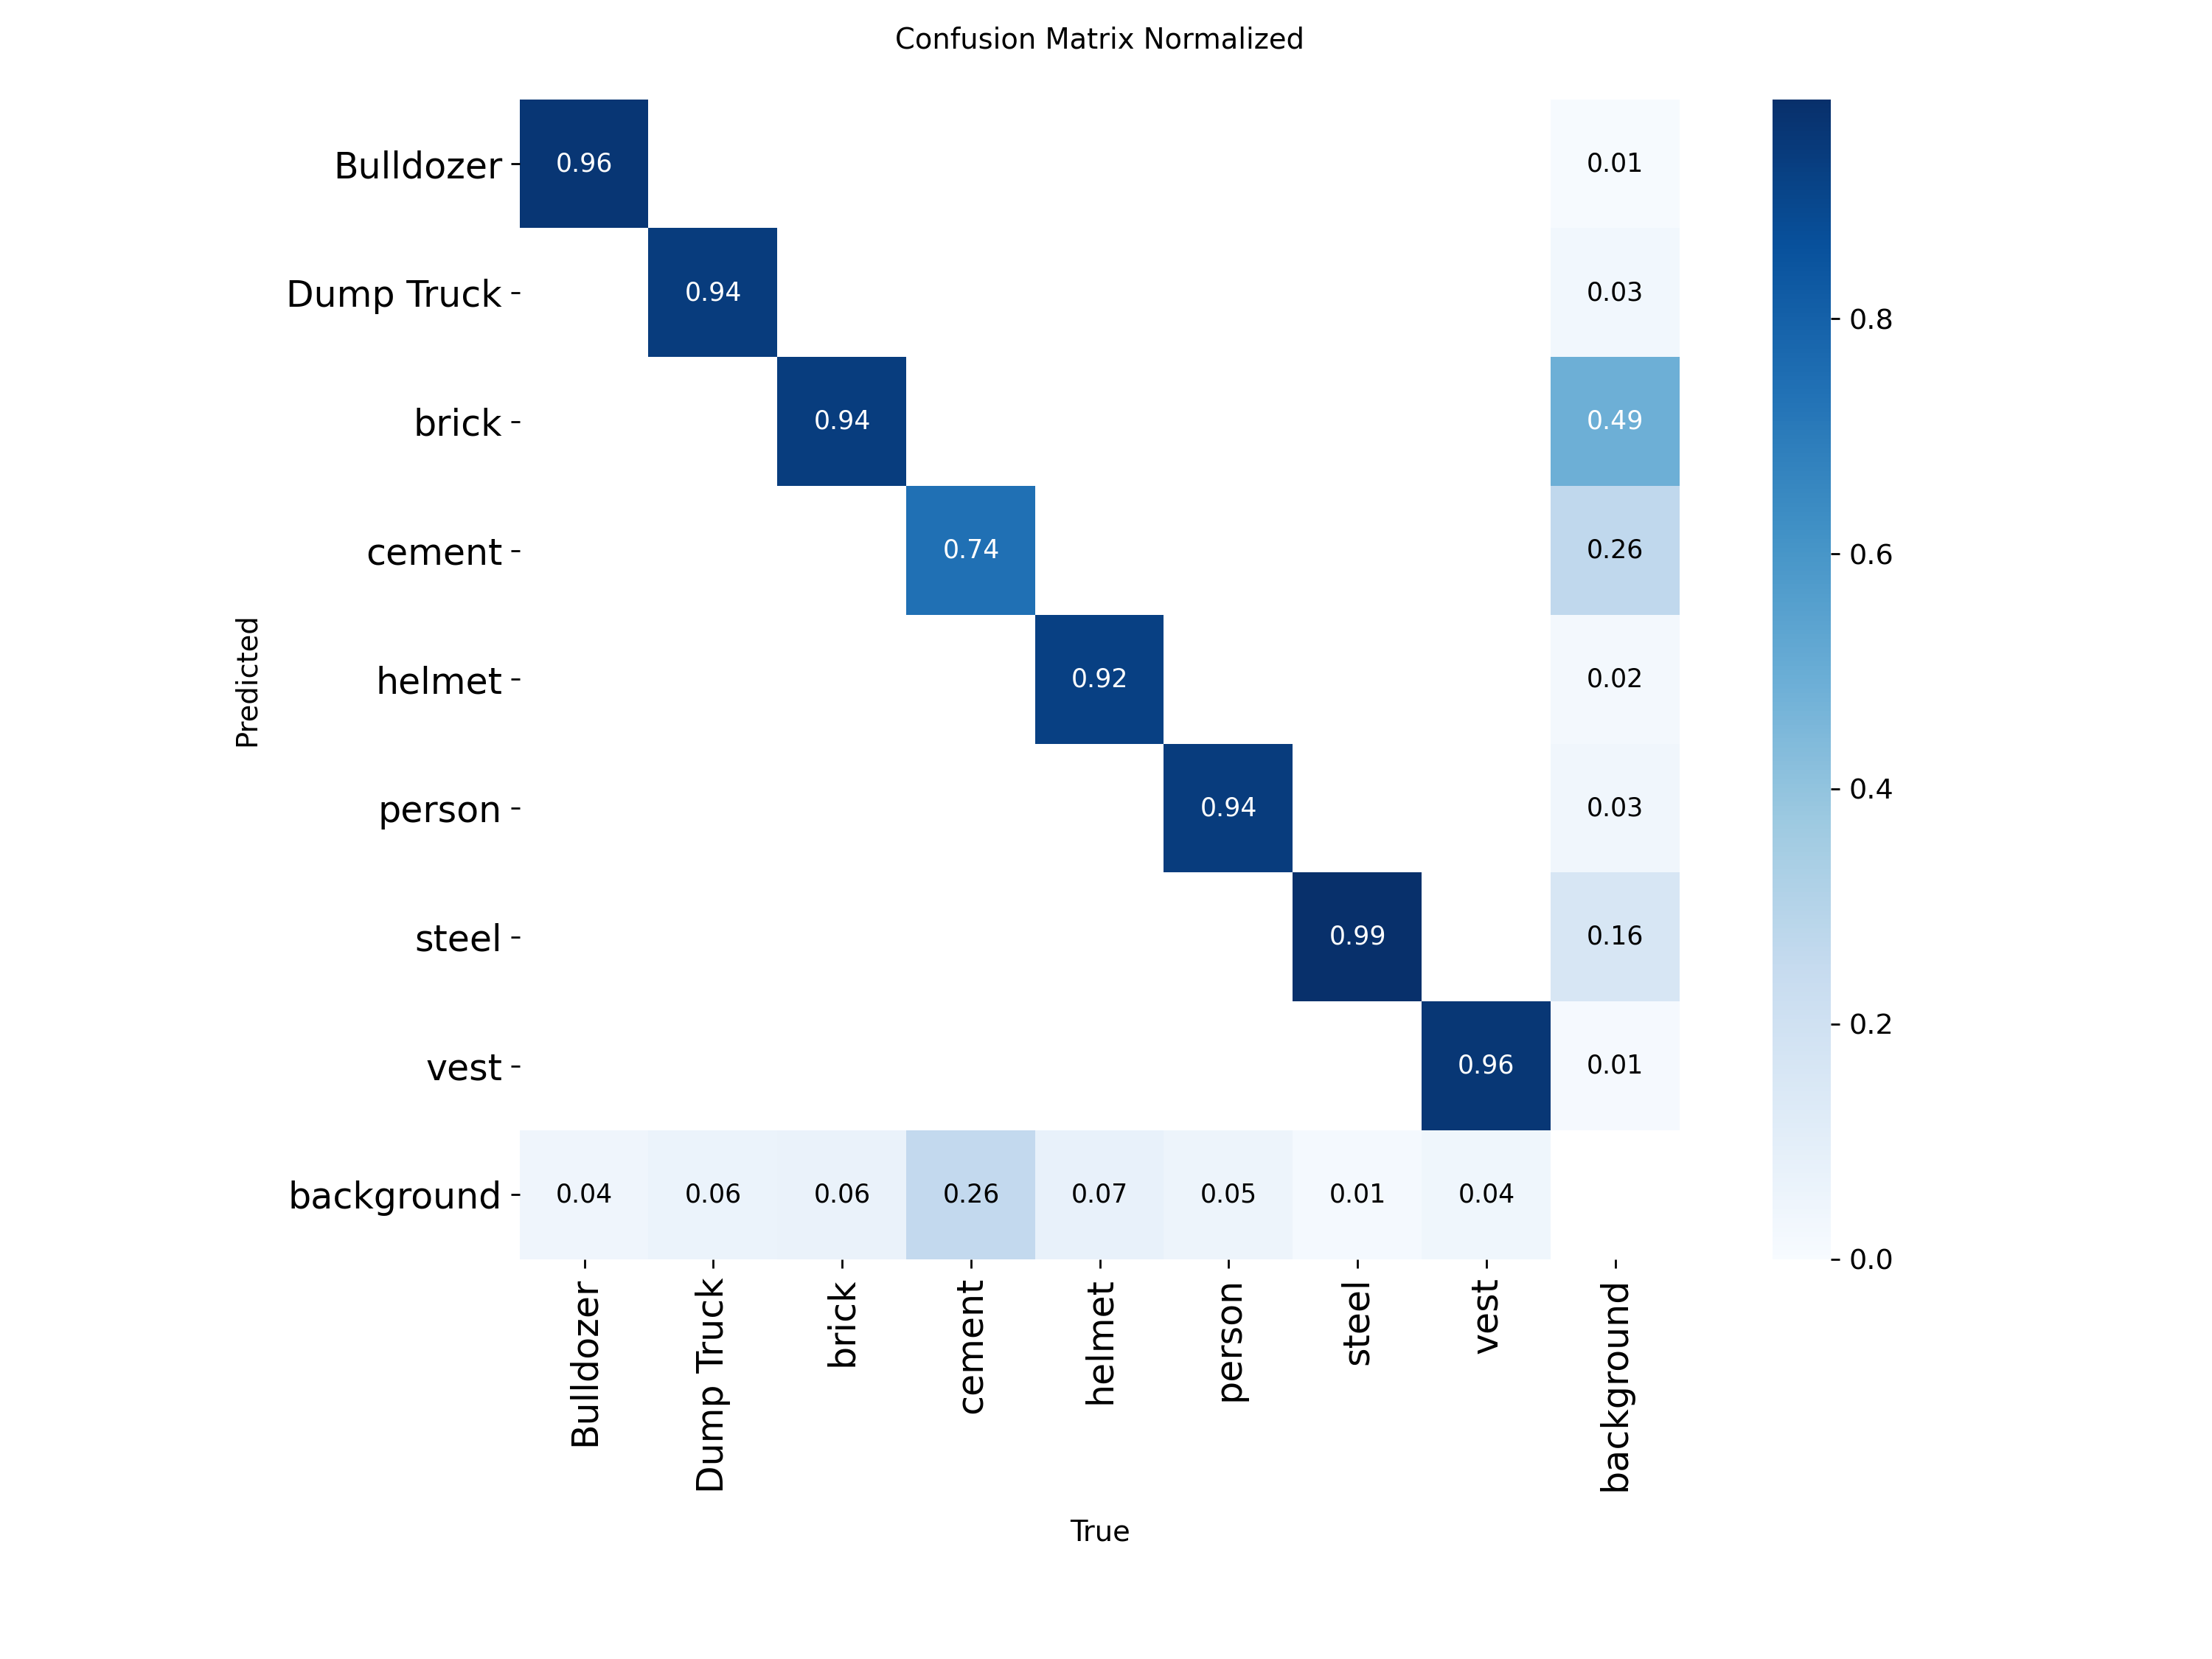

--- confusion_matrix.png ---


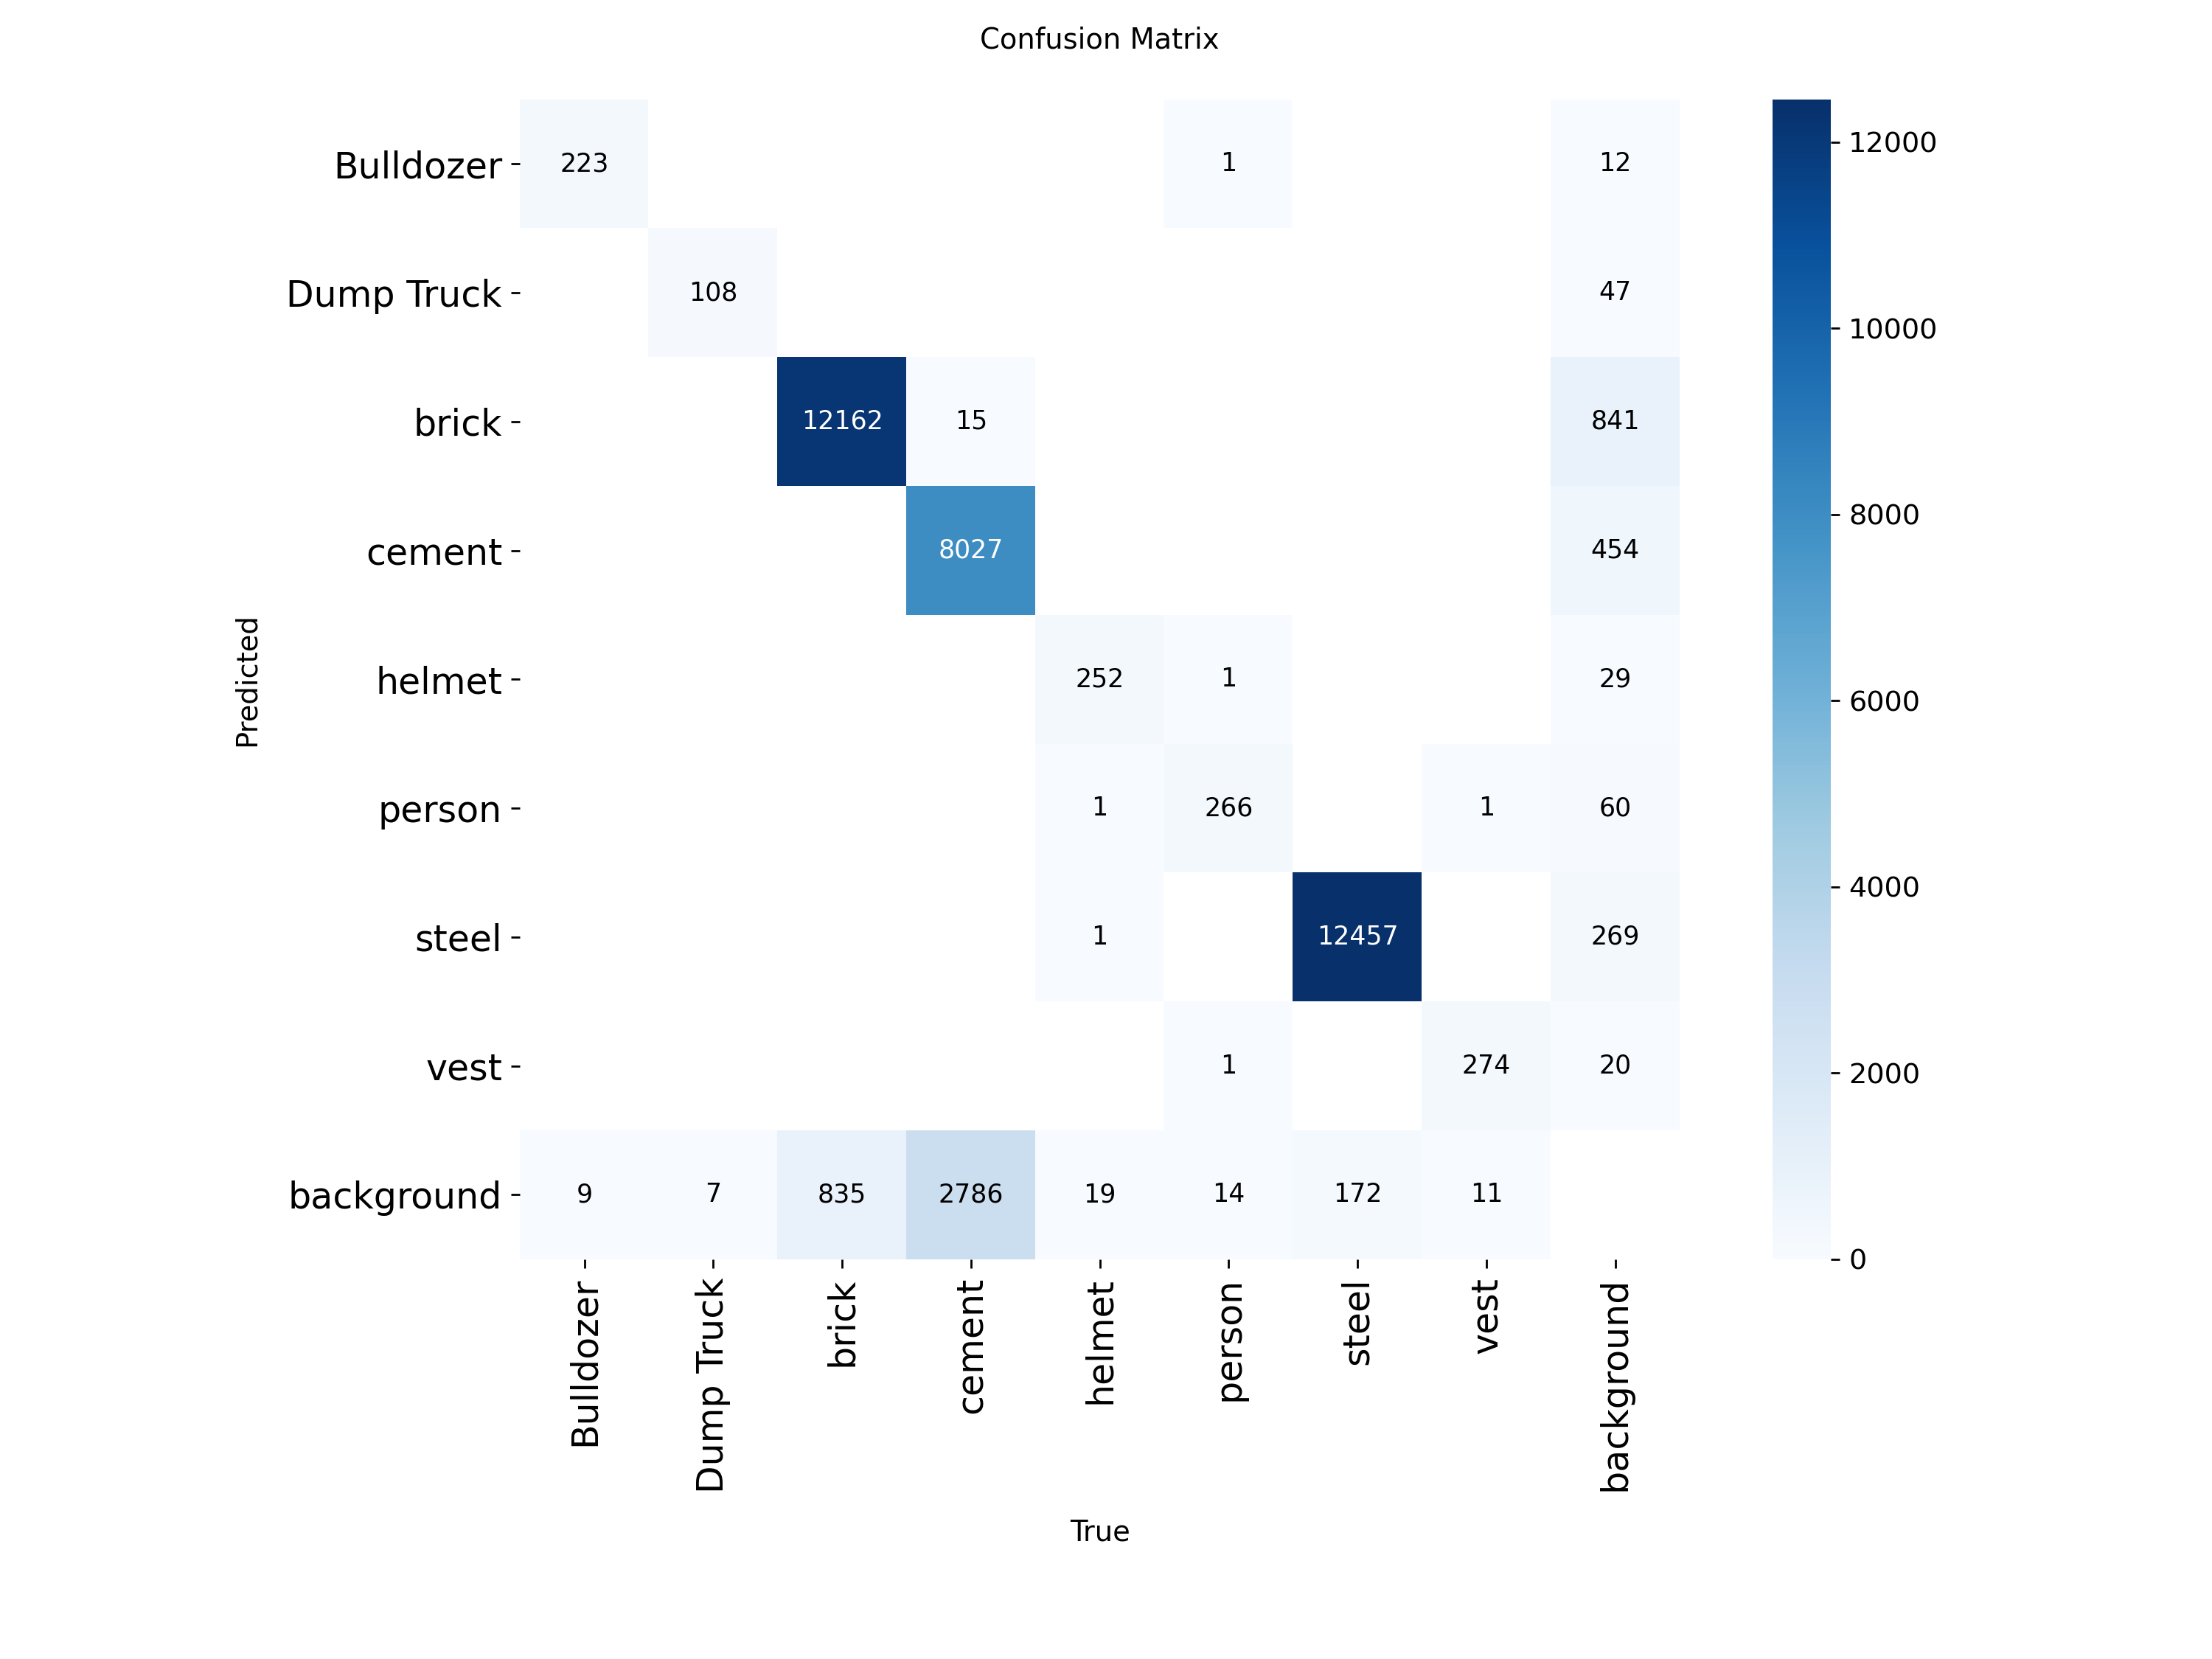

In [7]:
import glob
from IPython.display import Image, display

# Find all PNG plot files generated in the validation directory
val_dir = metrics.save_dir
plot_files = glob.glob(f"{val_dir}/*.png")

if not plot_files:
    print(f"No plots found in {val_dir}.")
    print("Run your validation cell again and add 'plots=True' like this:")
    print("metrics = model.val(data=dataset_yaml, split='test', plots=True)")
else:
    print(f"Found {len(plot_files)} validation plots. Displaying them now:\n")
    for plot_path in plot_files:
        # Extract just the filename to use as a title
        file_name = plot_path.split('/')[-1]
        print(f"--- {file_name} ---")
        display(Image(filename=plot_path, width=800))